<a href="https://colab.research.google.com/github/georginadd/EMSC2010-GP4-Oceans11Variables/blob/main/EMSC2010_GP4_numerical_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Ocean's Eleven Variables

Project week: 3 (Week 9)

Project title: Modelling the Change in Ocean carbon Storage over Time

Datasets used (name and source): Instead of a dataset, this project was based around a model. The model used was equation (2) in Yao et al. for the change in ocean carbon storage. The quantities used in our modelling were obtained from the sources listed below.


1.   Arora, VK, Katavouta, A, Williams, RG, Jones, CD, Brovkin, V, Friedlingstein,   P, Schwinger, J, Bopp, L, Boucher, O, Cadule, P, Chamberlain, MA, Christian, JR, Delire, C, Fisher, RA, Hajima, T, Ilyina, T, Joetzjer, E, Kawamiya, M, Koven, CD & Krasting, JP 2020, ‘Carbon–Concentration and Carbon–Climate Feedbacks in CMIP6 Models and Their Comparison to CMIP5 Models’, Biogeosciences, vol. 17, no. 16, pp. 4173–4222.

2.   Global Climate Highlights 2024 2025, Copernicus.eu, European Centre for Medium-Range Weather Forecasts.

3. Global Monitoring Laboratory - Carbon Cycle Greenhouse Gases n.d., Global Monitoring Laboratory.

4. Ward, K (ed.) 2026, Global Temperature – Earth Indicator, NASA Science.

5. Yao, W, Cao, L & Jin, X 2025, ‘Simulated Responses of the Ocean Carbon Cycle to Different Rates of Atmospheric CO2 Removal’, Journal of Geophysical Research Oceans, vol. 130, Wiley, no. 7.

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Georgie | Emily | Yes/Partial/No| Add note|
| Data steward | Emily | Leo | Yes/Partial/No| Add note|
| Analysis / modelling | Leo | Charlotte | Yes/Partial/No| Add note|
| Visualisation / interpretation | Charlotte | Jiah | Yes/Partial/No| Add note|
| Narrative | Jiah | Mel | Yes/Partial/No| Add note|
| Quality Control / Reproducibility  | Mel | Georgie | Yes/Partial/No/NA| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

**Introduction**

Currently the ocean absorbs roughly 25% of atmospheric carbon. However, as atmospheric C0<sub>2</sub> levels and surface air temperature change, the ocean is projected to become a source of carbon to the atmosphere.

The following model was used by Yao et al. to estimate the change in ocean carbon storage under different levels of atmospheric carbon removal:

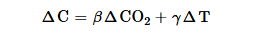

Where

ΔC = change in ocean C0<sub>2</sub> storage

ΔC0<sub>2</sub> = change in atmospheric C0<sub>2</sub> concentration

ΔT = change in global mean surface air temperature

β = ocean carbon-concentration sensitivity parameter (the ratio of change in cumulative ocean carbon uptake to change in atmospheric C0<sub>2</sub> concentration ΔC/ΔC0<sub>2</sub>)

γ = ocean carbon-climate sensitivity parameter (the ratio of change in cumulative ocean carbon uptake to change in air temperature ΔC/ΔT)


---

We can use this model to estimate when (at current rates of atmospheric C0<sub>2</sub>  and temperature increase) the ocean will begin to release rather than sequester carbon.

According to the Global Monitoring Laboratory [3], atmospheric C0<sub>2</sub>  concentration increased by 2.12 ppm in the year 2025. Compared to a 2024 concentration of 422.79ppm [3], this gives an increase of 0.50%. At this rate, the atmospheric C0<sub>2</sub>  concentration each year is equal to 1.0050 times the previous year's, or 1.01 when rounded to 2 decimal places (the level of precision in the source data).

The global land-ocean temperature anomaly from 2024-2025 was 1.19˚C [4], which, with a 2024 average surface temperature of 15.10˚C [2], gives an increase of 7.88%. At this rate, each year's surface temperature is 1.08 times the previous year's.

Yao et al. gives β = 0.87 PgC/ppm and γ = -11.78 PgC/K at current temperature and C0<sub>2</sub>  levels, obtained through methods outlined in Arora et al. [1].

In [ ]:
# Import required packages for data handling, plotting, modelling, and model comparison.

import numpy as np
import matplotlib.pyplot as plt


We imported all the required libraries necessary for our modelling.

In [ ]:
# Leo's code
# Model parameters
B = 0.87        # PgC/ppm
Y = -11.78     # PgC/K

# Initial conditions (2024 values)
CO2_0 = 422.79     # ppm
T_0 = 15.10        # °C

# Annual changes
dCO2 = 2.12        # ppm/year
dT = 0.0788        # °C/year

# Number of years to simulate
years = 10

The sensitivity parameters from Yao et al. were then defined. These parameters quantify how ocean carbon storage responds to changes in atmospheric CO<sub>2</sub> concentration and global temperature. The positive effect of increasing atmospheric CO<sub>2</sub> on ocean carbon uptake is represented by the parameter β, whereas the parameter γ represents the negative effect of rising temperature on ocean carbon storage.

In [ ]:
time = np.arange(years + 1)

CO2 = np.zeros(years + 1)
Temp = np.zeros(years + 1)
DeltaC = np.zeros(years + 1)

# Set initial values
CO2[0] = CO2_0
Temp[0] = T_0

Initial atmospheric concentration of CO<sub>2</sub> and global mean surface temperature values were established using 2024 datasets. These observations provide the baseline conditions from which future yearly changes were evidently projected throughout the sampling simulation.

In [ ]:
for i in range(years):

    # Update atmospheric CO2
    CO2[i+1] = CO2[i] + dCO2

    # Update temperature
    Temp[i+1] = Temp[i] + dT

    # Ocean carbon storage change
    DeltaC[i+1] = (B * dCO2) + (Y * dT)

print("Annual ocean carbon storage change:")
print(DeltaC[1], "PgC/year")

Annual ocean carbon storage change:
0.9161360000000002 PgC/year


Observed annual CO<sub>2</sub> concentration and global mean surface temperature increases and were incorporated into our model to estimate future climatic conditions. The model therefore, assumes these annual values remain constant over the entire simulation period, showcasing a more simplified projection of future ocean carbon storage trends.

In [ ]:
DeltaC < 0

source_years = np.where(DeltaC < 0)[0]

if len(source_years) > 0:
    print("Ocean becomes a carbon source in year:", source_years[0])
else:
    print("Ocean remains a carbon sink during simulation.")

Ocean remains a carbon sink during simulation.


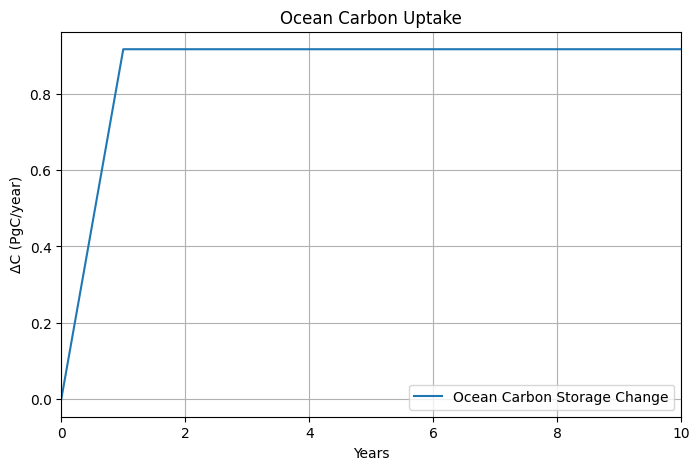

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(time, DeltaC, label='Ocean Carbon Storage Change')

plt.xlabel('Years')
plt.ylabel('ΔC (PgC/year)')
plt.title('Ocean Carbon Uptake')
plt.grid(True)
plt.xlim(0,10)
plt.legend(loc = 'lower right')

plt.show()

The first plot illustrates the annual projection in ocean carbon storage (ΔC) in the 10-year simulation period beginning in 2024. This indicares whether the ocean continues to work out as a carbon sink or it sort of transitions into a carbon source under the influence of atmospheric CO<sub>2</sub> rates increasing and global warming.

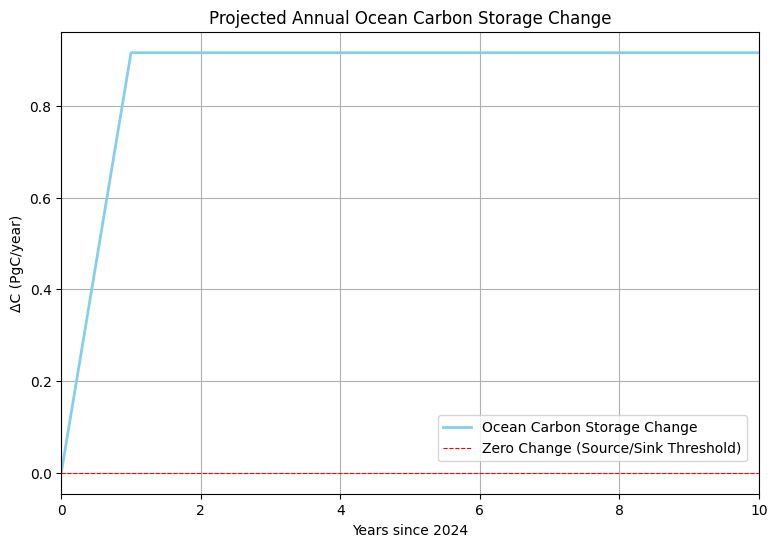

In [ ]:
#Charlotte coding

#Graph modelling the Ocean Carbon Storage Change over 10 years since 2024
plt.figure(figsize=(9,6))

plt.plot(time, DeltaC, label='Ocean Carbon Storage Change', color='skyblue', linewidth=2)

plt.xlabel('Years since 2024')
plt.ylabel('ΔC (PgC/year)')
plt.title('Projected Annual Ocean Carbon Storage Change')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero Change (Source/Sink Threshold)')
plt.legend(loc='lower left', bbox_to_anchor=(0.53, 0.055))
plt.grid(True)
plt.xlim(0,10)
plt.tight_layout

plt.show()

The visualisation created demonstrates that ΔC remains above the zero-threshold line (horizontal line shown in the graph) during the simulation period. Thus the ocean does not transition into a carbon source under the model assumptions.





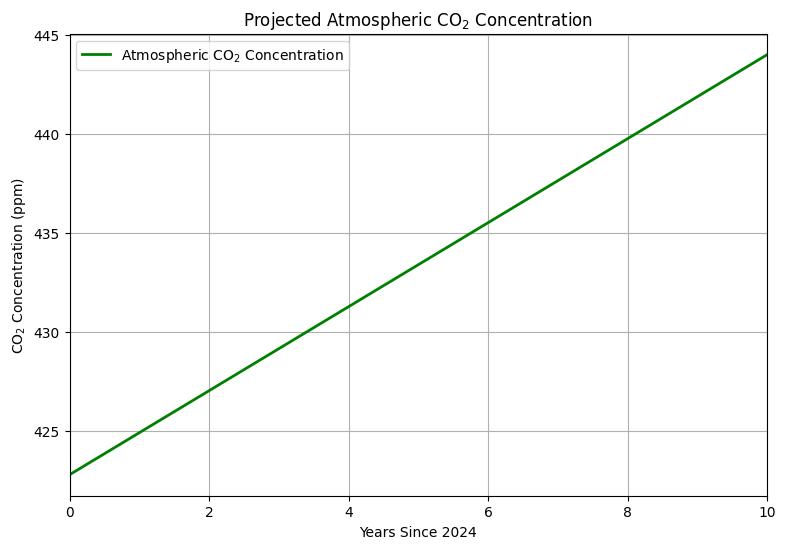

In [ ]:
#Graph modelling the Atmospheric CO2 Concentration over 10 years since 2024
plt.figure(figsize=(9,6))

plt.plot(time, CO2, label='Atmospheric CO$_2$ Concentration', color='green', linewidth=2)
plt.xlabel('Years Since 2024')
plt.ylabel('CO$_2$ Concentration (ppm)')
plt.title('Projected Atmospheric CO$_2$ Concentration')
plt.xlim(0, 10)
plt.grid(True)
plt.legend()
plt.tight_layout

plt.show()

This illustration evidently indicates a steady increase in atmospheric CO<sub>2</sub> concentration over time, reflecting the constant accumulation of greenhouse gases in the atmosphere.

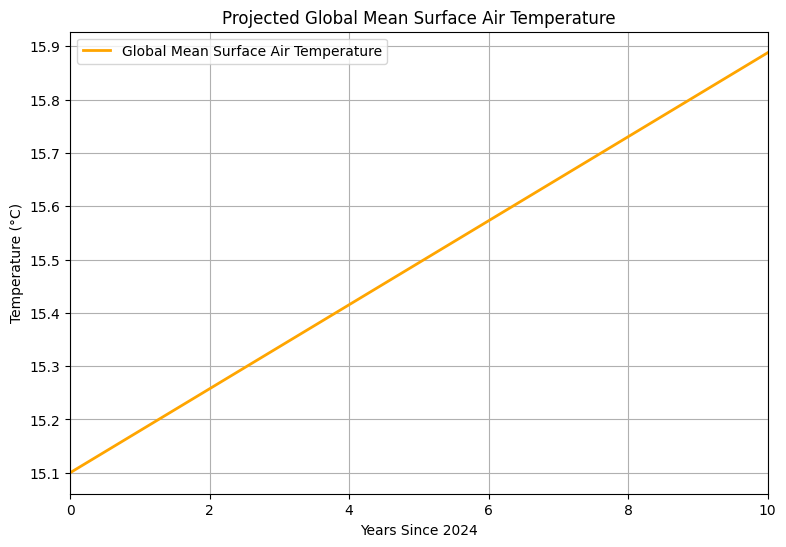

In [ ]:
#Graph modelling the Global Mean Surface Air Temperature over 10 years since 2024
plt.figure(figsize=(9,6))

plt.plot(time, Temp, label='Global Mean Surface Air Temperature', color='orange', linewidth=2)
plt.xlabel('Years Since 2024')
plt.ylabel('Temperature (°C)')
plt.title('Projected Global Mean Surface Air Temperature')
plt.xlim(0, 10)
plt.grid(True)
plt.legend()
plt.tight_layout

plt.show()

The plot visualises a gradual yet steady rise in global mean surface air temperature throughout the simulation period of 10 years, consistent with ongoing global warming trends.

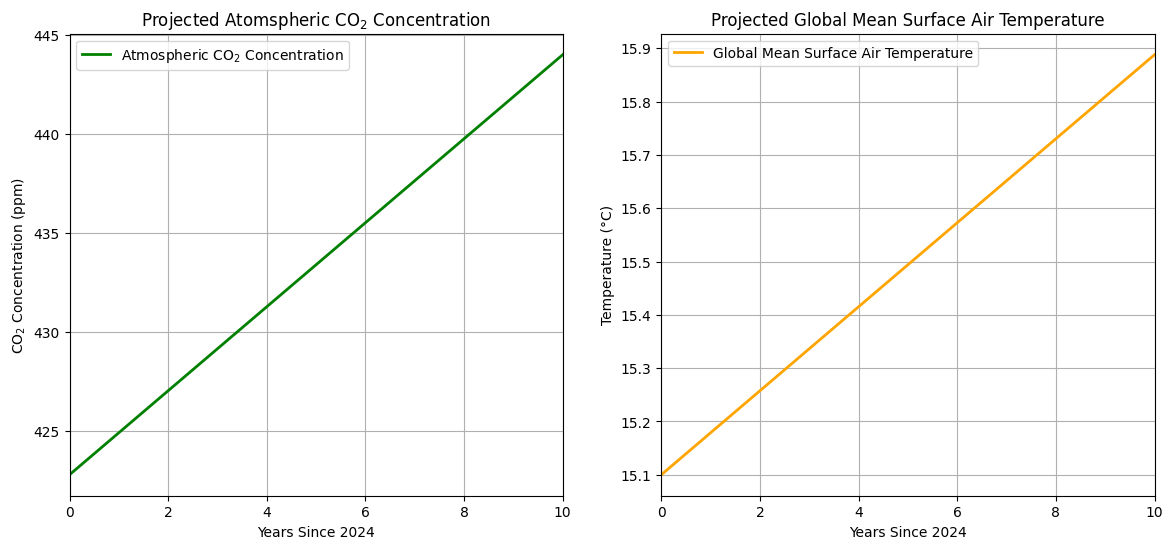

In [ ]:
#Subplots of Atmospheric CO2 Concentration and Global Mean Surface Air Temperature side by side
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.plot(time, CO2, label='Atmospheric CO$_2$ Concentration', color='green', linewidth=2)
plt.xlabel('Years Since 2024')
plt.ylabel('CO$_2$ Concentration (ppm)')
plt.title('Projected Atomspheric CO$_2$ Concentration')
plt.xlim(0, 10)
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(time, Temp, label='Global Mean Surface Air Temperature', color='orange', linewidth=2)
plt.xlabel('Years Since 2024')
plt.ylabel('Temperature (°C)')
plt.title('Projected Global Mean Surface Air Temperature')
plt.xlim(0, 10)
plt.grid(True)
plt.legend()

plt.tight_layout
plt.show()

The side-by-side plots show that both atmospheric CO<sub>2</sub> concentration and temperature increase over time. Despite rising temperatures reducing ocean carbon uptake, increasing atmospheric CO2]<sub>2</sub> continues to dominate, allowing the ocean to remain a carbon sink.

**How accurate do we think this model and assumptions are?**

The model provides a useful simplified projection of future ocean carbon storage, but its accuracy is limited by several assumptions. It assumes constant annual increases in atmospheric CO<sub>2</sub>
concentration and temperature, whereas real-world climate systems are more variable and influenced by changing emissions and natural climate processes.

The model also assumes a linear relationship between ocean carbon uptake, atmospheric CO<sub>2</sub>, and temperature, despite ocean carbon cycling being far more complex. In addition, the sensitivity parameters (β and γ) are treated as constant throughout the simulation.

Therefore, the model should be viewed as a first-order approximation rather than an exact prediction, although it remains useful for demonstrating overall trends in ocean carbon storage under current conditions.


**Conclusion**

The DeltaC plot above shows that for the simulated 10 years, the change in ocean carbon storage remains positive. This implies that despite the increasing temperature, the ocean is projected to continue acting as a carbon sink during this period, absorbing more carbon than it releases. The output *Ocean remains a carbon sink during simulation* further confirms this observation. The side-by-side plots of CO<sub>2</sub> concentration and temperature clearly demistrates a continuous increase in both over the 10 years. The ocean's ability to continue acting as a sink during this period implies that the positive effect of increasing CO<sub>2</sub> concentration currently outweighs the negative effect of increasing temperature as per the model parameters and annual rates of change used.

**Week 8 Group Project Reflections:**

**Leo:** For the group project this week, I was assigned to the Analysis/Data Modelling role. My main focus was on assigning the values to short hand code making later graphing and calculations flow more easily. I used numerical modelling to mathematically represet the change in ocean carbon storage under different levels of atmospheric carbon removal via the formula provided at the top of this notebook. I modelled the parameters and their annual changes initially before coding in a range that would create a loop to calculate the change in atm, CO<sub>2</sub>, temperature change, and the change in ocean carbon storage. I then plotted the change in carbon over years.

**Jiah:** As the Narrative Lead, my role was to interpret the model outputs and communicate the scientific findings clearly and logically throughout the report. I ensured that the coding process, graphs, and results were supported with concise explanations that linked the model back to the broader climate science context. This role also involved improving the overall flow, readability, and coherence of the project to make the analysis accessible and scientifically accurate.

**Mel**: As the Quality Control, my role had the duty of making sure the notebook worked, was clear and could be reproduced by others. I fixed any spelling mistakes, correcting grammar whilst also formatting them correctly, such as subscripting CO<sub>2</sub>. Furthermore I also added minor cosmetic details to the graph to ensure clarity, such as rearranging legends or adding gridlines.  All in all this role allowed me to understand the benefit of a cleaned final product, as a coherent text makes the code more accessible to a wider audience, and improves upon the initial draft for submission.

**Charlotte:** My role for this week was Visualisation and Interpretation. My main roles were to produce figure/graphes for our model, make sure the axis and other graph elements were labelled properly and interpret the graphes in relation to the chosen model. For my role, I created graphs to demonstrate the projected atmospheric CO2 concentration and projected global mean surface air temperature as according to our model. I enjoyed doing this role as it allowed me to have more practice with my coding and the creation of graphs from code.

**Emily**: The Data Steward role was replaced with Model Steward for this week. My role was to find a model we could use to answer a research question. It took a little while to find something suitable, as a lot of the topics we were interested in involved quite complex maths, but the equation we decided on was very simple. To give more depth to our project, I did some research to find out why the model worked and how it had been used previously, and then collated some data we could plug into it. I found the research component very enjoyable, and the topic was something I had an interest in, so I had a lot of fun doing this role.

**Georgie:** My role this week was role 1; Github and Integration. I created and shared the colab with the group and ensured everyone could access it. I also committed it back to Github after the project was completed. Everything ran smoothly and I’m now more comfortable with the setup of Github and working a shared colab.